In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import seaborn as sns

In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df["Product Category"].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


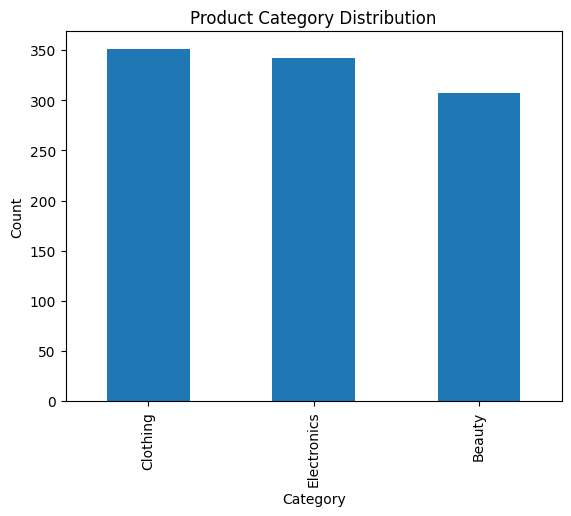

In [ ]:
import matplotlib.pyplot as plt

df["Product Category"].value_counts().plot(kind="bar")

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [ ]:
df["Product Category"].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [ ]:
df.groupby("Product Category")["Total Amount"].sum()

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


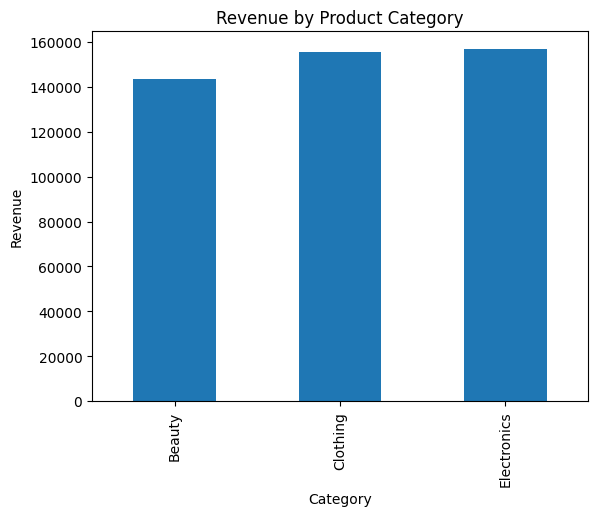

In [ ]:
df.groupby("Product Category")["Total Amount"].sum().plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [ ]:
df["Gender"].value_counts()


,count
Gender,
Female,510
Male,490


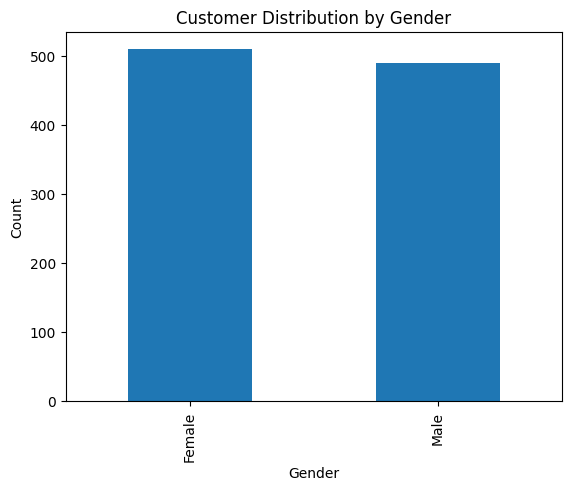

In [ ]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [ ]:
df.groupby("Gender")["Total Amount"].sum()

,Total Amount
Gender,
Female,232840
Male,223160


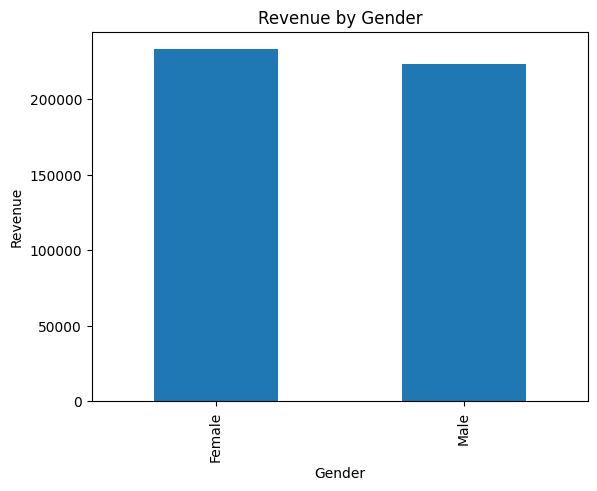

In [ ]:
df.groupby("Gender")["Total Amount"].sum().plot(kind="bar")

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")

plt.show()

In [ ]:
df["Age"].describe()


,Age
count,1000.00000
mean,41.39200
std,13.68143
min,18.00000
25%,29.00000
50%,42.00000
75%,53.00000
max,64.00000


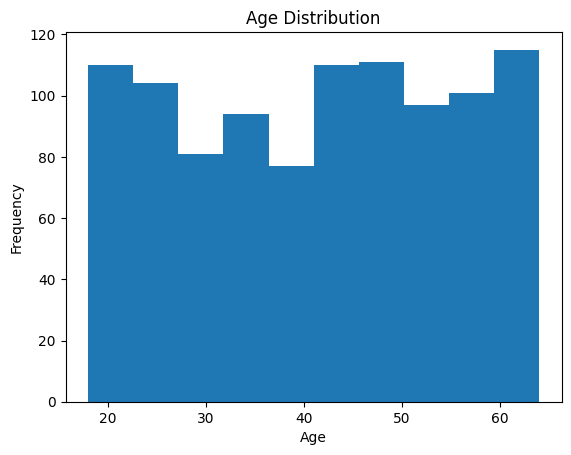

In [ ]:
df["Age"].plot(kind="hist", bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,60],
    labels=["18-25","26-35","36-45","46-60"]
)

df.groupby("Age Group")["Total Amount"].sum()

/tmp/ipykernel_1320/3535680537.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Total Amount"].sum()


,Total Amount
Age Group,
18-25,73335
26-35,98480
36-45,91870
46-60,147875


/tmp/ipykernel_1320/2416984335.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Total Amount"].sum().plot(kind="bar")


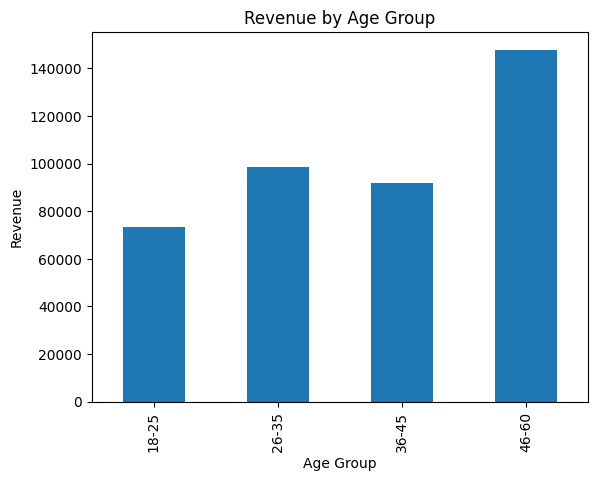

In [ ]:
df.groupby("Age Group")["Total Amount"].sum().plot(kind="bar")

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")

plt.show()

In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Total Amount"].sum()

monthly_sales

,Total Amount
Date,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


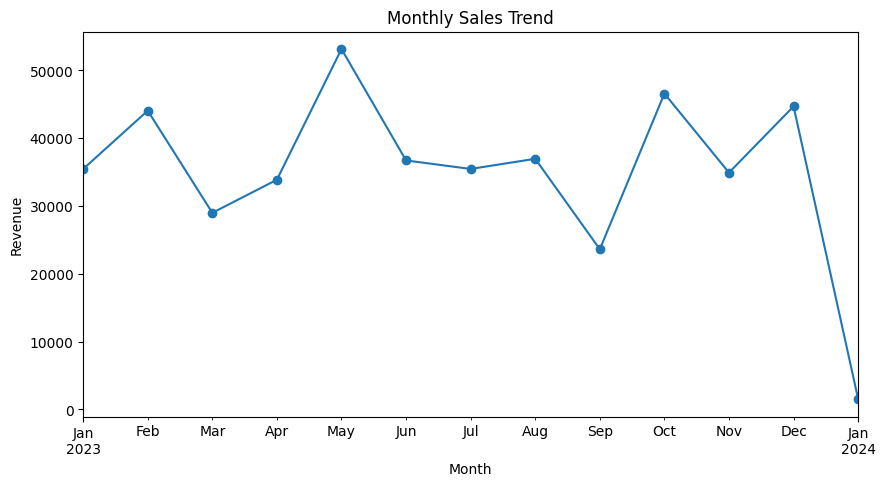

In [ ]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [ ]:
monthly_sales.idxmax(), monthly_sales.max()

(Period('2023-05', 'M'), 53150)

In [ ]:
pivot = df.pivot_table(
    values="Total Amount",
    index="Gender",
    columns="Product Category",
    aggfunc="sum"
)

pivot

Product Category,Beauty,Clothing,Electronics
Gender,,,
Female,74830,81275,76735
Male,68685,74305,80170


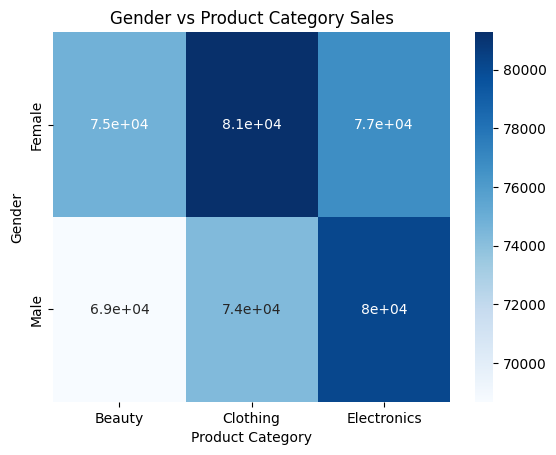

In [ ]:
sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues"
)

plt.title("Gender vs Product Category Sales")

plt.show()